<a href="https://colab.research.google.com/github/andersonmoraix/analisedeconjuntura_anotacoes/blob/main/aula08_analisedomercadodecredito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AULA: Análise do mercado de crédito com R e Python<br>
AUTOR: Fernando da Silva/Cientista de dados<br>
INFORMAÇÕES: saiba mais sobre o tema nas referências abaixo<br>
F. J. C. Carvalho, F. E. P. Souza, J. Sicsu, L. F. R. Paula, and R. Studart.
Economia Monetária e Financeira - Teoria e Política. Elsevier, Rio de Janeiro, sétima edition, 2000.<br>
A. A. Neto. Mercado Financeiro. Editora Atlas, 2012.

# Bibliotecas e Softwares

In [ ]:
# Baixa e descompacta o X13-ARIMA-SEATS (Linux)
# Docs: https://www.census.gov/data/software/x13as.X-13ARIMA-SEATS.html
!wget https://aluno.analisemacro.com.br/wp-content/uploads/dlm_uploads/2025/08/x13as_ascii-v1-1-b62.tar.gz
!tar --gunzip --extract --verbose --file=x13as_ascii-v1-1-b62.tar.gz

# Instala outras bibliotecas python
!pip install sidrapy
!pip install python-bcb

--2025-08-30 20:39:08--  https://aluno.analisemacro.com.br/wp-content/uploads/dlm_uploads/2025/08/x13as_ascii-v1-1-b62.tar.gz
Resolving aluno.analisemacro.com.br (aluno.analisemacro.com.br)... 170.82.174.30, 170.82.173.30
Connecting to aluno.analisemacro.com.br (aluno.analisemacro.com.br)|170.82.174.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3837943 (3.7M) [application/octet-stream]
Saving to: ‘x13as_ascii-v1-1-b62.tar.gz’

x13as_ascii-v1-1-b6 100%[===================>]   3.66M  6.26MB/s    in 0.6s    

2025-08-30 20:39:10 (6.26 MB/s) - ‘x13as_ascii-v1-1-b62.tar.gz’ saved [3837943/3837943]

x13as/
x13as/docs/
x13as/docs/docX13AS.pdf
x13as/docs/qrefX13ASunix.pdf
x13as/testairline.spc
x13as/x13as_ascii


In [ ]:
# Importa módulos
import pandas as pd
import sidrapy as sidra
from bcb import sgs
from statsmodels.tsa import x13
import os

# Coleta de dados

In [ ]:
# Parâmetros e códigos para coleta de dados
codigos = {
  # Concessões de crédito - Total - R$ (milhões)
  "Concessões de crédito - Total": 20631,

  # Concessões de crédito - Pessoas jurídicas - Total - R$ (milhões)
  "Concessões de crédito - PJ": 20632,

  # Concessões de crédito - Pessoas físicas - Total	- R$ (milhões)
  "Concessões de crédito - PF": 20633,

  # Concessões de crédito com recursos livres - Total	- R$ (milhões)
  "Concessões de crédito - Livre": 20634,

  # Concessões de crédito com recursos direcionados - Total	- R$ (milhões)
  "Concessões de crédito - Direcionado": 20685,

  # Saldo da carteira de crédito - Total - R$ (milhões)
  "Saldo da carteira de crédito - Total": 20539,

  # PIB acumulado dos últimos 12 meses - Valores correntes - (R$ milhões)
  "PIB acumulado dos últimos 12 meses": 4382,

  # Saldos das operações de crédito sob controle privado - Total	- (R$ milhões)
  "Saldos de crédito - Privado": 2043,

  # Saldos das operações de crédito sob controle público - Total	- (R$ milhões)
  "Saldos de crédito - Público": 2007,

  # Taxa média de juros das operações de crédito - Total - % a.a.
  "Taxa média de juros das operações de crédito": 20714,

  # Spread médio das operações de crédito - Total	- p.p.
  "Spread médio das operações de crédito": 20783,

  # Inadimplência da carteira de crédito - Total - %
  "Inadimplência da carteira de crédito": 21082

}

# Importa dados do SGS/BCB
dados = sgs.get(codes = codigos, start = "2012-01-01")
dados

,Concessões de crédito - Total,Concessões de crédito - PJ,Concessões de crédito - PF,Concessões de crédito - Livre,Concessões de crédito - Direcionado,Saldo da carteira de crédito - Total,PIB acumulado dos últimos 12 meses,Saldos de crédito - Privado,Saldos de crédito - Público,Taxa média de juros das operações de crédito,Spread médio das operações de crédito,Inadimplência da carteira de crédito
Date,,,,,,,,,,,,
2012-01-01,214365,116230,98134,192708,21656,2033185,4412978.2,1144812,888373,26.80,18.22,3.66
2012-02-01,204149,111611,92539,182427,21723,2041040,4448189.5,1146273,894768,26.86,18.63,3.71
2012-03-01,241689,139145,102544,215826,25863,2078912,4489325.5,1163169,915743,26.54,18.41,3.67
2012-04-01,232678,131809,100869,207523,25155,2106585,4520600.5,1172206,934379,25.96,18.21,3.76
2012-05-01,255850,145295,110556,226037,29814,2142061,4554181.4,1183595,958466,24.36,16.96,3.76
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-01,619922,282606,337316,560920,59003,6579506,12011089.1,3801419,2777087,31.25,19.46,3.28
2025-04-01,644258,295331,348927,573332,70925,6630471,12091688.1,3833825,2796647,31.53,20.10,3.50
2025-05-01,647475,299703,347772,578928,68547,6663997,12173618.6,3854823,2809174,31.69,20.50,3.54


In [ ]:
# Importa dados do IPCA
ipca = sidra.get_table(
    table_code = "1737",
    territorial_level = "1",
    ibge_territorial_code = "all",
    variable = "2266",
    period = "all"
    )
ipca

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,Variável (Código),Variável
1,1,Brasil,30,Número-índice,0.0000000076183,1,Brasil,197912,dezembro 1979,2266,IPCA - Número-índice (base: dezembro de 1993 =...
2,1,Brasil,30,Número-índice,0.0000000081223,1,Brasil,198001,janeiro 1980,2266,IPCA - Número-índice (base: dezembro de 1993 =...
3,1,Brasil,30,Número-índice,0.0000000084973,1,Brasil,198002,fevereiro 1980,2266,IPCA - Número-índice (base: dezembro de 1993 =...
4,1,Brasil,30,Número-índice,0.0000000090104,1,Brasil,198003,março 1980,2266,IPCA - Número-índice (base: dezembro de 1993 =...
...,...,...,...,...,...,...,...,...,...,...,...
544,1,Brasil,30,Número-índice,7245.3800000000000,1,Brasil,202503,março 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...
545,1,Brasil,30,Número-índice,7276.5400000000000,1,Brasil,202504,abril 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...
546,1,Brasil,30,Número-índice,7295.4600000000000,1,Brasil,202505,maio 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...
547,1,Brasil,30,Número-índice,7312.9700000000000,1,Brasil,202506,junho 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...


# Tratamento de dados

In [ ]:
ipca

,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Mês (Código),Mês,Variável (Código),Variável
1,1,Brasil,30,Número-índice,0.0000000076183,1,Brasil,197912,dezembro 1979,2266,IPCA - Número-índice (base: dezembro de 1993 =...
2,1,Brasil,30,Número-índice,0.0000000081223,1,Brasil,198001,janeiro 1980,2266,IPCA - Número-índice (base: dezembro de 1993 =...
3,1,Brasil,30,Número-índice,0.0000000084973,1,Brasil,198002,fevereiro 1980,2266,IPCA - Número-índice (base: dezembro de 1993 =...
4,1,Brasil,30,Número-índice,0.0000000090104,1,Brasil,198003,março 1980,2266,IPCA - Número-índice (base: dezembro de 1993 =...
...,...,...,...,...,...,...,...,...,...,...,...
544,1,Brasil,30,Número-índice,7245.3800000000000,1,Brasil,202503,março 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...
545,1,Brasil,30,Número-índice,7276.5400000000000,1,Brasil,202504,abril 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...
546,1,Brasil,30,Número-índice,7295.4600000000000,1,Brasil,202505,maio 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...
547,1,Brasil,30,Número-índice,7312.9700000000000,1,Brasil,202506,junho 2025,2266,IPCA - Número-índice (base: dezembro de 1993 =...


In [ ]:
# Trata dados do SGS
dados.rename_axis("data", inplace = True)

# Trata dados do IPCA
ipca = (
    ipca
    .rename(columns = ipca.iloc[0])
    .rename(columns = {"Mês (Código)": "data", "Valor": "ipca"})
    .query("ipca not in 'Valor'")
    .filter(items = ["data", "ipca"], axis = "columns")
    .assign(
        data = lambda x: pd.to_datetime(x.data, format = "%Y%m"),
        ipca = lambda y: y.ipca.astype(float)
        )
    .set_index("data")
)
ipca

,ipca
data,
1979-12-01,7.618300e-09
1980-01-01,8.122300e-09
1980-02-01,8.497300e-09
1980-03-01,9.010400e-09
1980-04-01,9.486700e-09
...,...
2025-03-01,7.245380e+03
2025-04-01,7.276540e+03
2025-05-01,7.295460e+03


# Visualização de dados

In [ ]:
# Objeto com fonte dos dados
fonte = "Dados: BCB | Elaboração: analisemacro.com.br"

### Concessões

<Axes: title={'center': 'Concessões de crédito - Total\nValores nominais\nDados: BCB | Elaboração: analisemacro.com.br'}, ylabel='R$ bilhões'>

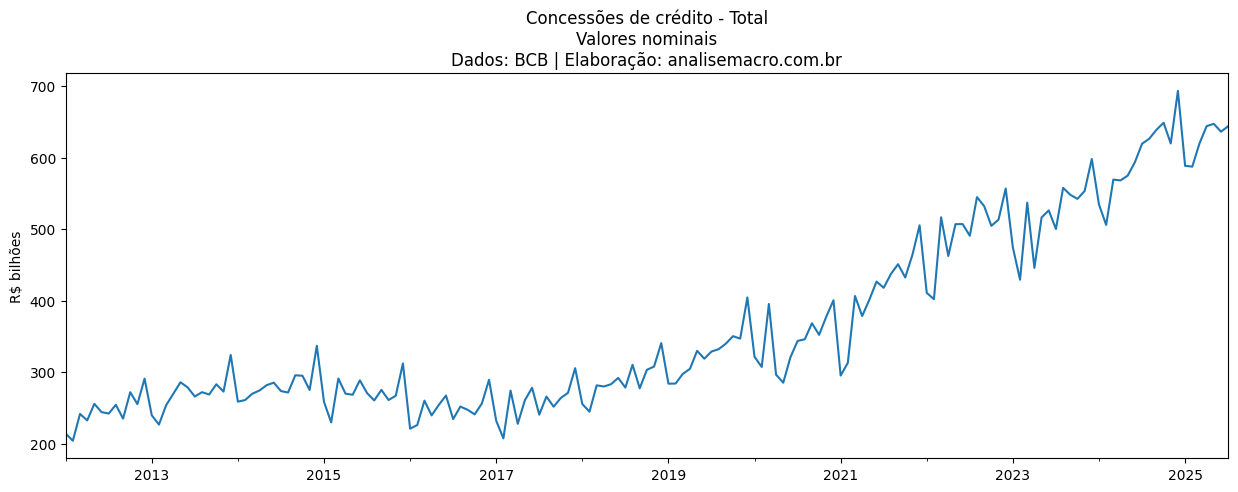

In [ ]:
# Total - Nominal
(dados["Concessões de crédito - Total"] / 1000).plot(
    title = "Concessões de crédito - Total\nValores nominais\n" + fonte,
    xlabel = "",
    ylabel = "R$ bilhões",
    figsize = (15, 5)
    )

array([[<Axes: ylabel='R$ bilhões'>, <Axes: ylabel='R$ bilhões'>],
       [<Axes: ylabel='R$ bilhões'>, <Axes: ylabel='R$ bilhões'>]],
      dtype=object)

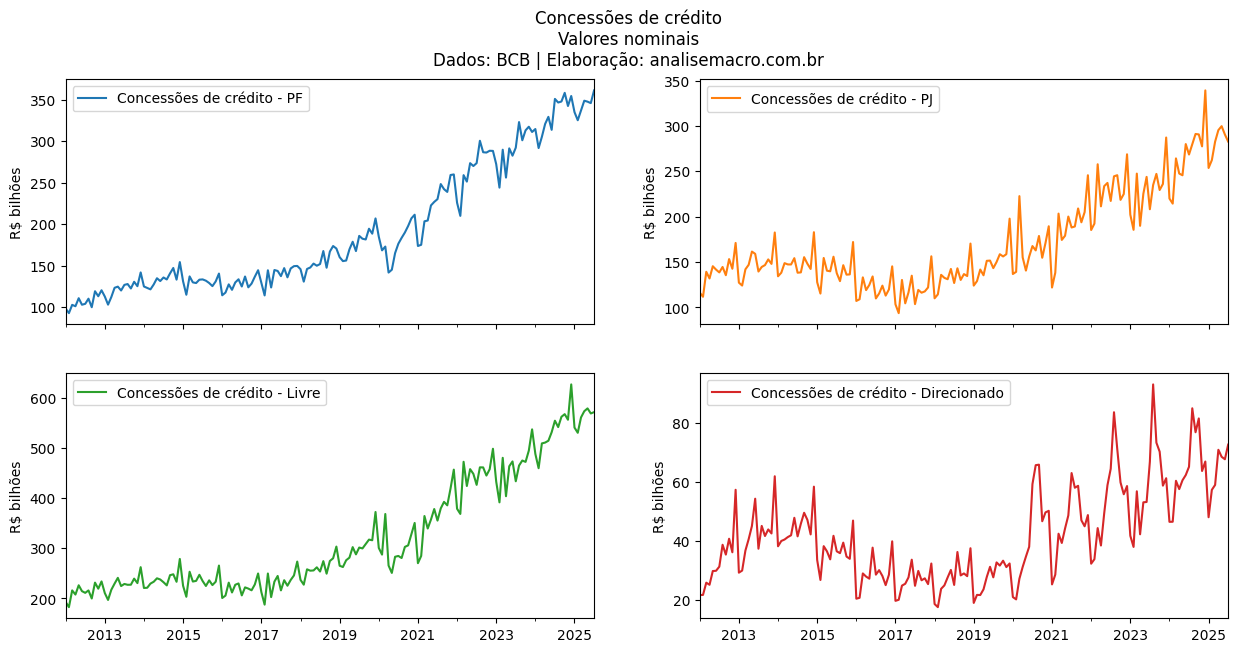

In [ ]:
# PF/PJ e Livre/Direcionado - Nominal
(
    dados[["Concessões de crédito - PF", "Concessões de crédito - PJ",
           "Concessões de crédito - Livre", "Concessões de crédito - Direcionado"]] / 1000
 ).plot(
    title = "Concessões de crédito\nValores nominais\n" + fonte,
    xlabel = "",
    ylabel = "R$ bilhões",
    figsize = (15, 7),
    subplots = True,
    layout = (2, 2)
    )

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/x13.py:192: X13Warning: WARNING: At least one visually significant trading day peak has been
          found in the estimated spectrum of the regARIMA residuals.
  
          found in one or more of the estimated spectra.
  warn(errors, X13Warning)


<Axes: title={'center': 'Concessões de crédito - Total\nValores deflacionados pelo IPCA a preços de Jul/2025 e ajustado sazonalmente pelo X13-SEATS-ARIMA.\nDados: BCB/IBGE | Elaboração: analisemacro.com.br'}, ylabel='R$ bilhões'>

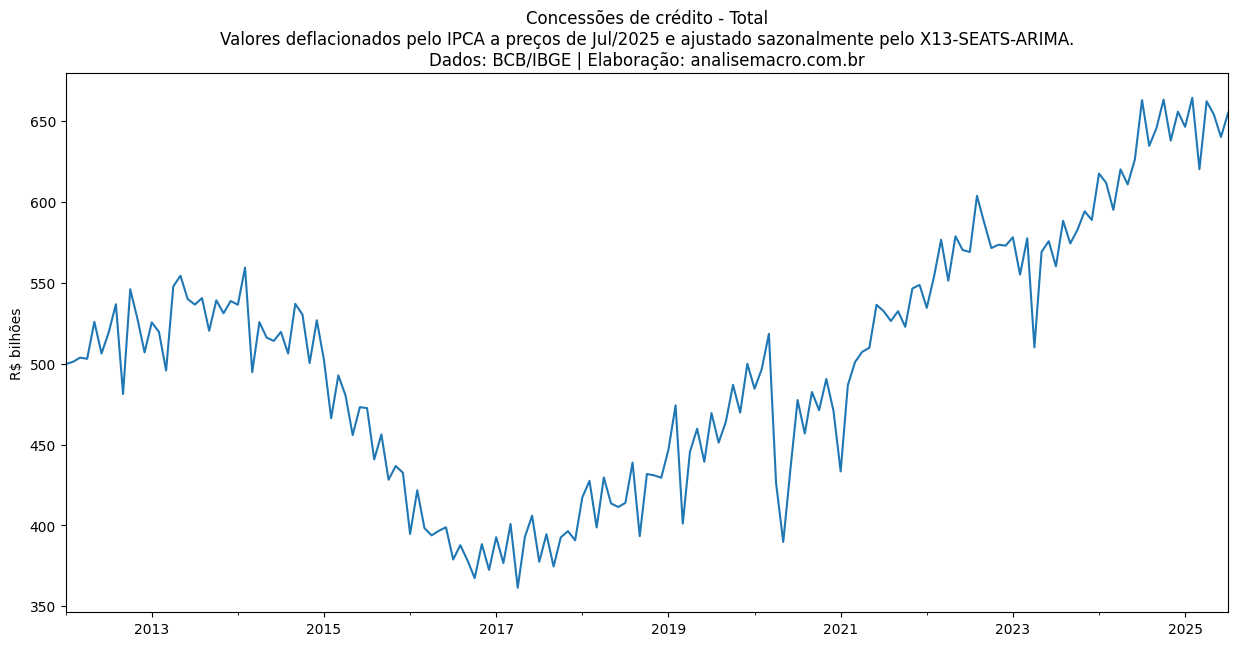

In [ ]:
# Total - Deflacionado e dessazonalidado
os.environ["X13PATH"] = "/content/x13as/" # caminho do programa X13

concessoes = ( # tratamentos e cálculos
    pd.merge(
        left = dados["Concessões de crédito - Total"],
        right = ipca,
        on = "data"
        )
    .assign(
        deflacionado = lambda x: (x.ipca.iloc[-1] / x.ipca * x["Concessões de crédito - Total"]),
        ajuste = lambda x: x13.x13_arima_analysis(endog = x.deflacionado / 1000, prefer_x13 = True, freq = "M").seasadj
    )
)

concessoes.ajuste.plot( # gráfico
    title = "Concessões de crédito - Total\n" +
    "Valores deflacionados pelo IPCA a preços de " +
    concessoes.tail(1).index.strftime("%b/%Y").item() +
    " e ajustado sazonalmente pelo X13-SEATS-ARIMA." +
    "\nDados: BCB/IBGE | Elaboração: analisemacro.com.br",
    xlabel = "",
    ylabel = "R$ bilhões",
    figsize = (15, 7)
    )

### Estoque

<Axes: title={'center': 'Estoque de Crédito\nDados: BCB | Elaboração: analisemacro.com.br'}, ylabel='% do PIB'>

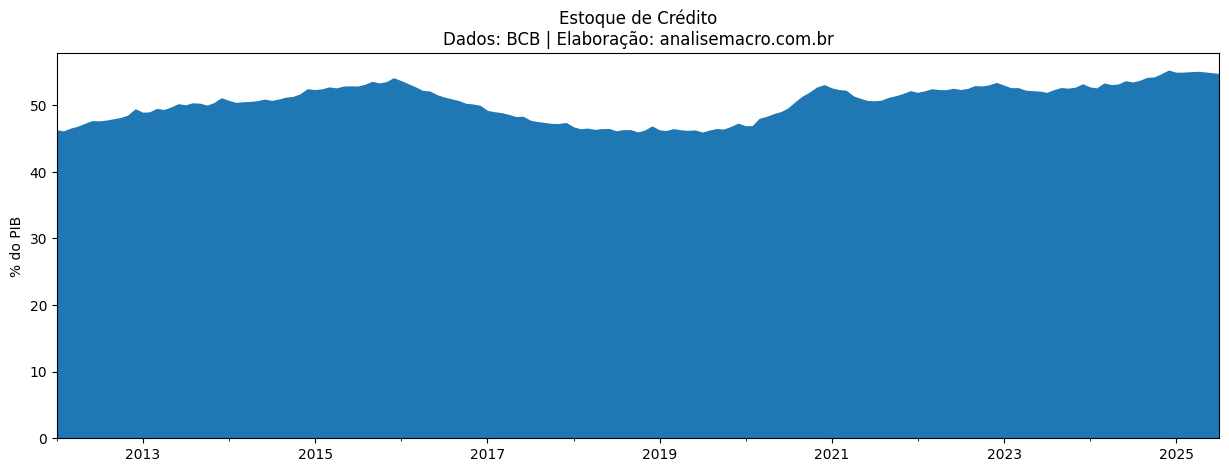

In [ ]:
# Saldo % do PIB
(
    dados["Saldo da carteira de crédito - Total"] / dados["PIB acumulado dos últimos 12 meses"] * 100
 ).plot(
    title = "Estoque de Crédito\n" + fonte,
    xlabel = "",
    ylabel = "% do PIB",
    figsize = (15, 5),
    kind = "area"
    )

<Axes: title={'center': 'Estoque de Crédito\nDados: BCB | Elaboração: analisemacro.com.br'}, ylabel='% do Total'>

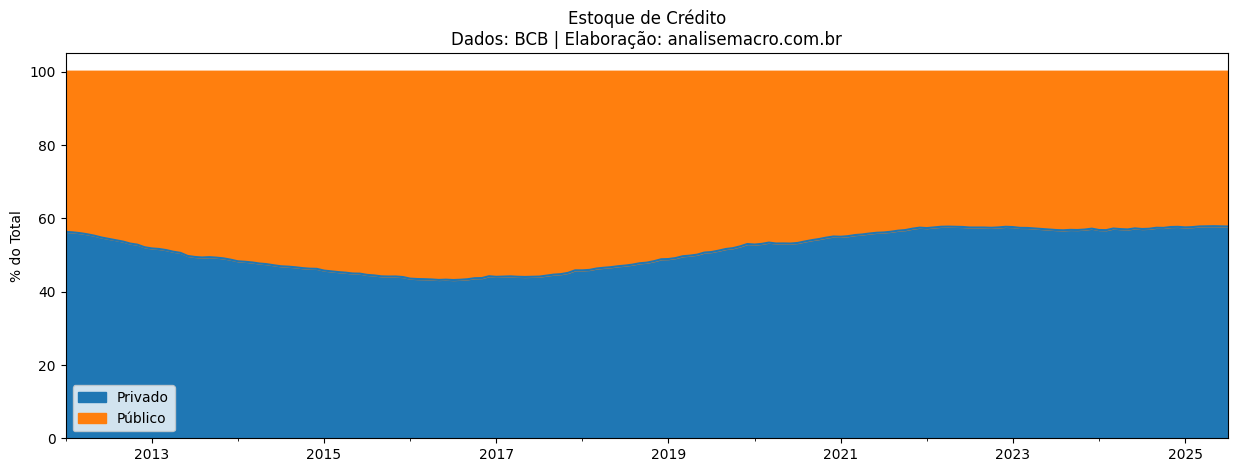

In [ ]:
# Privado/Publico % do Total
(
    dados
    .assign(
        Privado = lambda x: x["Saldos de crédito - Privado"] / x["Saldo da carteira de crédito - Total"] * 100,
        Público = lambda x: x["Saldos de crédito - Público"] / x["Saldo da carteira de crédito - Total"] * 100
        )
    .filter(items = ["Privado", "Público"], axis = "columns")
    .plot(
        title = "Estoque de Crédito\n" + fonte,
        xlabel = "",
        ylabel = "% do Total",
        figsize = (15, 5),
        kind = "area"
        )
)

### Taxa de juros

<Axes: title={'center': 'Taxa de juros - Mercado de Crédito - Brasil\nDados: BCB | Elaboração: analisemacro.com.br'}, ylabel='% a.a.'>

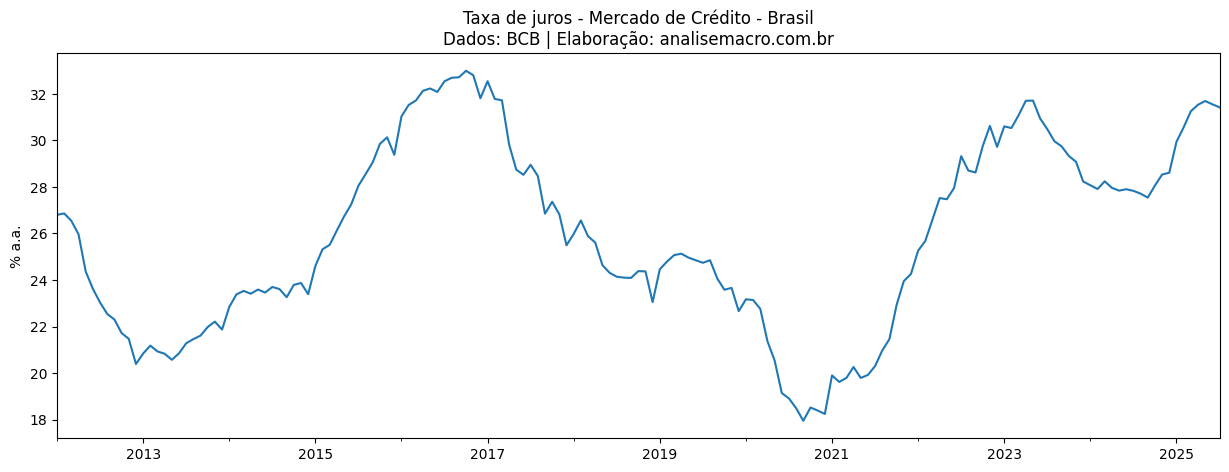

In [ ]:
# Gráfico de linha
dados["Taxa média de juros das operações de crédito"].plot(
    title = "Taxa de juros - Mercado de Crédito - Brasil\n" + fonte,
    xlabel = "",
    ylabel = "% a.a.",
    figsize = (15, 5)
    )

### Spread

<Axes: title={'center': 'Spread bancário - Mercado de Crédito - Brasil\nDados: BCB | Elaboração: analisemacro.com.br'}, ylabel='p.p.'>

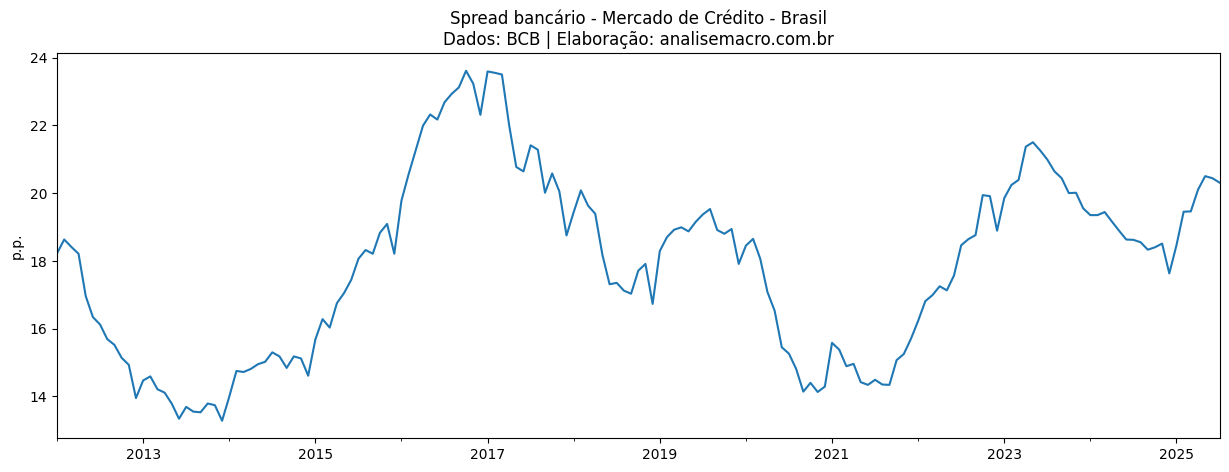

In [ ]:
# Gráfico de linha
dados["Spread médio das operações de crédito"].plot(
    title = "Spread bancário - Mercado de Crédito - Brasil\n" + fonte,
    xlabel = "",
    ylabel = "p.p.",
    figsize = (15, 5)
    )

### Inadimplência

<Axes: title={'center': 'Inadimplência - Mercado de Crédito - Brasil\nDados: BCB | Elaboração: analisemacro.com.br'}, ylabel='%'>

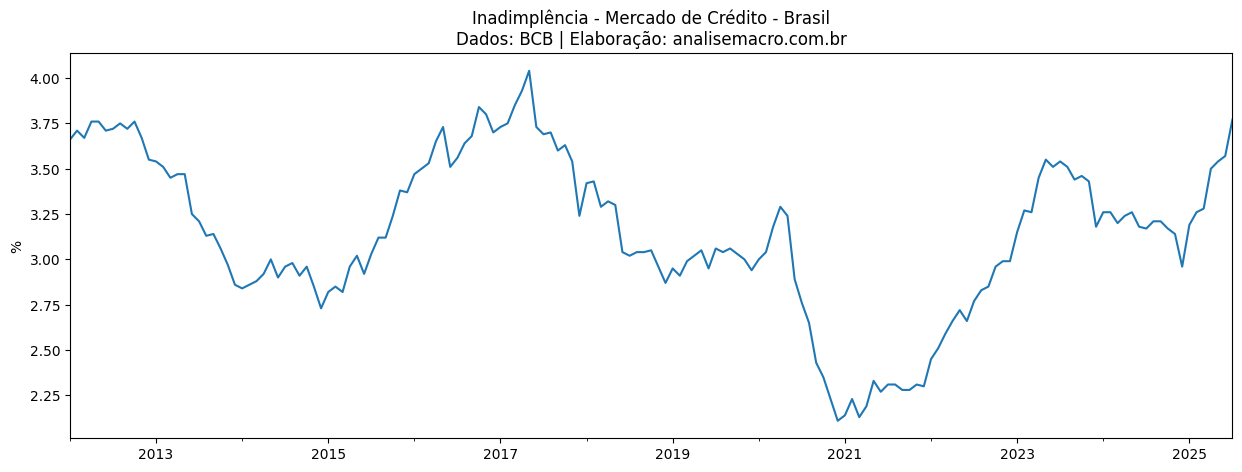

In [ ]:
# Gráfico de linha
dados["Inadimplência da carteira de crédito"].plot(
    title = "Inadimplência - Mercado de Crédito - Brasil\n" + fonte,
    xlabel = "",
    ylabel = "%",
    figsize = (15, 5)
    )